In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/df_cleaned.csv')

In [ ]:
df.shape

(326327, 24)

In [ ]:
df['Date Rptd'] = pd.to_datetime(df['Date Rptd'], format='%Y-%m-%d')
df['DATE OCC'] = pd.to_datetime(df['DATE OCC'], format='%Y-%m-%d')

In [ ]:
df['TIME OCC'] = pd.to_datetime(df['TIME OCC'], format='%H:%M:%S').dt.time

In [ ]:
df['hour'] = pd.to_datetime(df['TIME OCC'], format='%H:%M:%S').dt.hour
df['day'] = df['DATE OCC'].dt.day_name()
df['month'] = df['DATE OCC'].dt.month
df['year'] = df['DATE OCC'].dt.year

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 326327 entries, 0 to 326326
Data columns (total 28 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   DR_NO           326327 non-null  int64         
 1   Date Rptd       326327 non-null  datetime64[ns]
 2   DATE OCC        326327 non-null  datetime64[ns]
 3   TIME OCC        326327 non-null  object        
 4   AREA            326327 non-null  int64         
 5   AREA NAME       326327 non-null  object        
 6   Rpt Dist No     326327 non-null  int64         
 7   Part 1-2        326327 non-null  int64         
 8   Crm Cd          326327 non-null  int64         
 9   Crm Cd Desc     326327 non-null  object        
 10  Mocodes         326327 non-null  object        
 11  Vict Age        326327 non-null  int64         
 12  Vict Sex        326327 non-null  object        
 13  Vict Descent    326327 non-null  object        
 14  Premis Cd       326327 non-null  flo

# **Final_Load_Prep**

## Crime Volume KPIs

### 1. Total Crimes

In [ ]:
total_crimes = len(df)
print(f"Total Crimes: {total_crimes}")

Total Crimes: 326327


### 2. Crime Growth Rate (MoM / YoY)

In [ ]:
df['DATE OCC'] = pd.to_datetime(df['DATE OCC'], errors='coerce')
# Group by year and month to get monthly crime counts
# Explicitly rename the series to ensure the index levels do not inherit 'DATE OCC'
monthly_crimes = df.groupby(
    [df['DATE OCC'].dt.year.rename('temp_year'),
     df['DATE OCC'].dt.month.rename('temp_month')]
).size().reset_index(name='crime_count') # Name the column for the counts

# Now, rename the columns to their final desired names
monthly_crimes.columns = ['year', 'month', 'crime_count']

# Create a date column for easier calculation of growth rate
monthly_crimes['date'] = pd.to_datetime(monthly_crimes['year'].astype(str) + '-' + monthly_crimes['month'].astype(str) + '-01')
monthly_crimes = monthly_crimes.sort_values('date').reset_index(drop=True)

# Calculate Month-over-Month (MoM) Growth Rate
monthly_crimes['MoM_growth'] = monthly_crimes['crime_count'].pct_change() * 100
print("Month-over-Month Crime Growth Rate:")
display(monthly_crimes[['date', 'crime_count', 'MoM_growth']].tail())

# Calculate Year-over-Year (YoY) Growth Rate
# Need at least two full years of data for meaningful YoY. Let's check available years.
years_in_data = monthly_crimes['year'].unique()
if len(years_in_data) > 1:
    yoy_crimes = monthly_crimes.copy()
    yoy_crimes['prev_year_crime'] = yoy_crimes.groupby('month')['crime_count'].shift(1) # shift by one year
    yoy_crimes['YoY_growth'] = ((yoy_crimes['crime_count'] - yoy_crimes['prev_year_crime']) / yoy_crimes['prev_year_crime']) * 100
    print("\nYear-over-Year Crime Growth Rate:")
    display(yoy_crimes[['date', 'crime_count', 'prev_year_crime', 'YoY_growth']].tail())
else:
    print("\nNot enough data (less than 2 years) to calculate meaningful Year-over-Year growth rate.")

Month-over-Month Crime Growth Rate:


,date,crime_count,MoM_growth
55,2024-08-01,332,8.852459
56,2024-09-01,373,12.349398
57,2024-10-01,365,-2.144772
58,2024-11-01,309,-15.342466
59,2024-12-01,201,-34.951456



Year-over-Year Crime Growth Rate:


,date,crime_count,prev_year_crime,YoY_growth
55,2024-08-01,332,7206.0,-95.392728
56,2024-09-01,373,6948.0,-94.631549
57,2024-10-01,365,7122.0,-94.875035
58,2024-11-01,309,6262.0,-95.065474
59,2024-12-01,201,6235.0,-96.776263


## Temporal KPIs (When Crime Happens)

### 3. Peak Hour Index (% of crimes happening in the busiest hour)

In [ ]:
hourly_crime_counts = df['hour'].value_counts()
peak_hour = hourly_crime_counts.idxmax()
peak_hour_crimes = hourly_crime_counts.max()
total_crimes = len(df)
peak_hour_index = (peak_hour_crimes / total_crimes) * 100

print(f"Busiest hour for crime: {peak_hour}:00")
print(f"Crimes in peak hour: {peak_hour_crimes}")
print(f"Total crimes: {total_crimes}")
print(f"Peak Hour Index: {peak_hour_index:.2f}% of crimes happen in the busiest hour.")

Busiest hour for crime: 20:00
Crimes in peak hour: 18765
Total crimes: 326327
Peak Hour Index: 5.75% of crimes happen in the busiest hour.


### 4. Night Crime Ratio

In [ ]:
# Define night hours (e.g., 9 PM to 5 AM)
night_crimes = df[(df['hour'] >= 21) | (df['hour'] < 5)]
night_crime_ratio = len(night_crimes) / len(df) * 100

print(f"Total crimes during night hours (9 PM - 5 AM): {len(night_crimes)}")
print(f"Night Crime Ratio: {night_crime_ratio:.2f}% of crimes occur during night hours.")

Total crimes during night hours (9 PM - 5 AM): 100859
Night Crime Ratio: 30.91% of crimes occur during night hours.


### 5. Weekend Crime Ratio

In [ ]:
# Weekend days are 'Saturday' and 'Sunday'
weekend_crimes = df[df['day'].isin(['Saturday', 'Sunday'])]
weekend_crime_ratio = len(weekend_crimes) / len(df) * 100

print(f"Total crimes on weekends: {len(weekend_crimes)}")
print(f"Weekend Crime Ratio: {weekend_crime_ratio:.2f}% of crimes occur on weekends.")

Total crimes on weekends: 101360
Weekend Crime Ratio: 31.06% of crimes occur on weekends.


## Spatial KPIs (Where Crime Happens)

### 6. Crime Rate by Area (Hotspots vs low-risk areas)

In [ ]:
crime_by_area = df['AREA NAME'].value_counts().reset_index()
crime_by_area.columns = ['AREA NAME', 'crime_count']
crime_by_area['crime_rate'] = (crime_by_area['crime_count'] / total_crimes) * 100

print("Crime Rate by Area:")
display(crime_by_area.sort_values(by='crime_count', ascending=False).head())
print("\nLow-risk Areas (least crimes):")
display(crime_by_area.sort_values(by='crime_count', ascending=True).head())

Crime Rate by Area:


,AREA NAME,crime_count,crime_rate
0,77th Street,28932,8.865953
1,Central,24560,7.526193
2,Southeast,23024,7.055500
3,Southwest,20539,6.293993
4,Hollywood,19694,6.035051



Low-risk Areas (least crimes):


,AREA NAME,crime_count,crime_rate
20,West LA,10203,3.126618
19,Devonshire,10460,3.205374
18,Foothill,10505,3.219164
17,Northeast,10553,3.233873
16,Topanga,10916,3.345111


### 7. Top 5 Area Concentration

Top 5 Areas with Highest Crime Concentration:


,AREA NAME,crime_count,crime_rate
0,77th Street,28932,8.865953
1,Central,24560,7.526193
2,Southeast,23024,7.055500
3,Southwest,20539,6.293993
4,Hollywood,19694,6.035051


/tmp/ipykernel_3204/179731916.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='crime_count', y='AREA NAME', data=top_5_areas, palette='viridis')


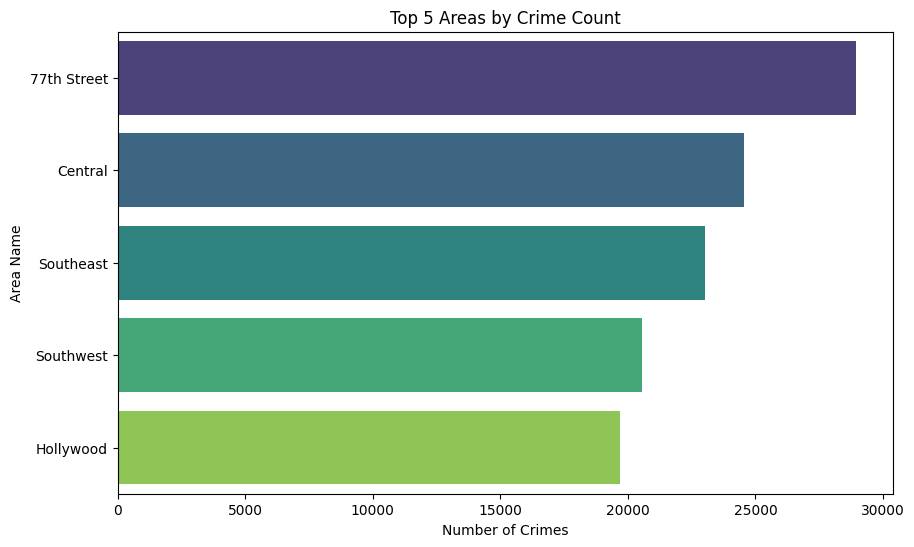

In [ ]:
top_5_areas = crime_by_area.head(5)
print("Top 5 Areas with Highest Crime Concentration:")
display(top_5_areas)

plt.figure(figsize=(10, 6))
sns.barplot(x='crime_count', y='AREA NAME', data=top_5_areas, palette='viridis')
plt.title('Top 5 Areas by Crime Count')
plt.xlabel('Number of Crimes')
plt.ylabel('Area Name')
plt.show()

## Crime Nature KPIs (What Type of Crime)

### 8. Top Crime Share

Top 10 Crime Types and their Share:


,Crime Type,Count,Share
0,BATTERY - SIMPLE ASSAULT,74704,22.892375
1,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",53451,16.379582
2,INTIMATE PARTNER - SIMPLE ASSAULT,46583,14.274945
3,ROBBERY,32219,9.873225
4,CRIMINAL THREATS - NO WEAPON DISPLAYED,19094,5.851186
5,BRANDISH WEAPON,14522,4.450137
6,INTIMATE PARTNER - AGGRAVATED ASSAULT,12655,3.878012
7,BURGLARY,7576,2.321598
8,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",6043,1.851823
9,ATTEMPTED ROBBERY,4826,1.478885


/tmp/ipykernel_3204/660597415.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Share', y='Crime Type', data=top_crime_types, palette='magma')


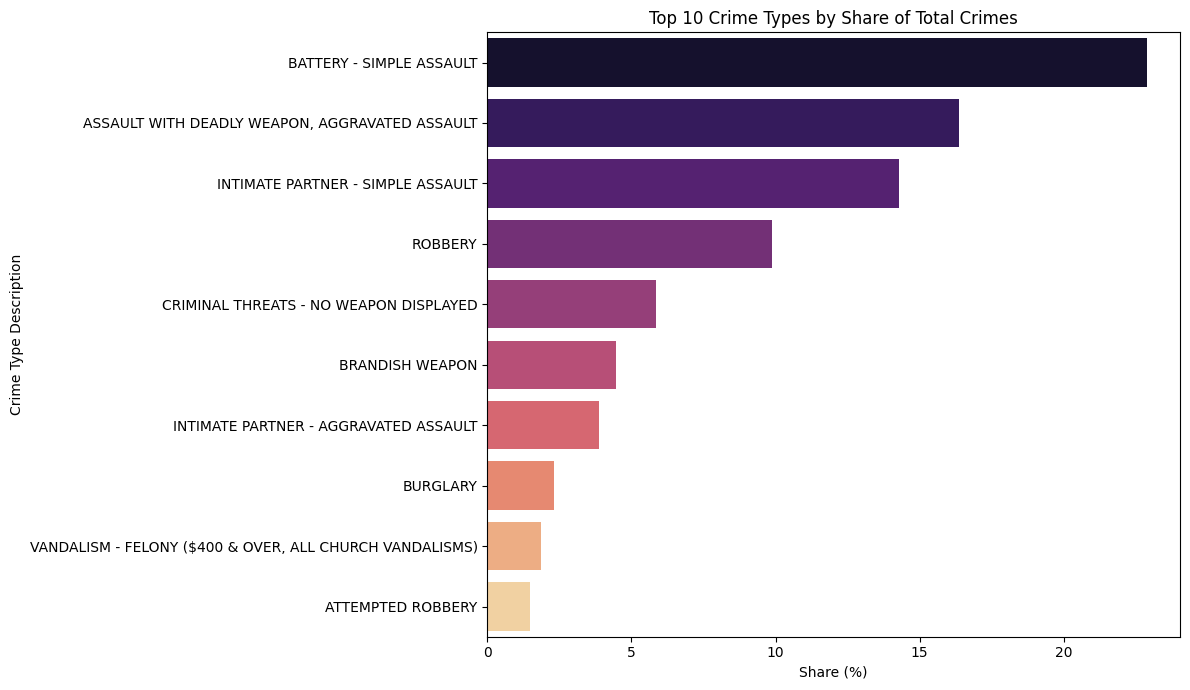

In [ ]:
crime_type_counts = df['Crm Cd Desc'].value_counts()
top_crime_types = crime_type_counts.head(10).reset_index()
top_crime_types.columns = ['Crime Type', 'Count']
top_crime_types['Share'] = (top_crime_types['Count'] / total_crimes) * 100

print("Top 10 Crime Types and their Share:")
display(top_crime_types)

plt.figure(figsize=(12, 7))
sns.barplot(x='Share', y='Crime Type', data=top_crime_types, palette='magma')
plt.title('Top 10 Crime Types by Share of Total Crimes')
plt.xlabel('Share (%)')
plt.ylabel('Crime Type Description')
plt.tight_layout()
plt.show()

## Victim KPIs (Who is Affected)

### 9. Average Victim Age

In [ ]:
average_victim_age = df['Vict Age'].mean()
print(f"Average Victim Age: {average_victim_age:.2f} years")

Average Victim Age: 37.26 years


### 10. High-Risk Age Group

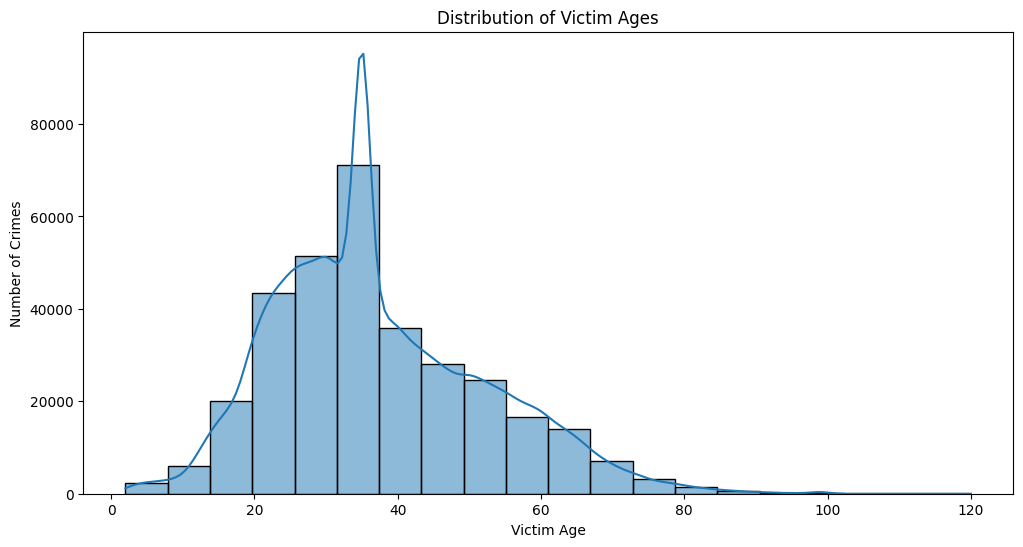

Crimes by Age Group:


,count
Age Group,
0-17,19646
18-24,44000
25-34,83278
35-49,111401
50-64,51249
65+,16752


/tmp/ipykernel_3204/4060344256.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_group_counts.index, y=age_group_counts.values, palette='plasma')


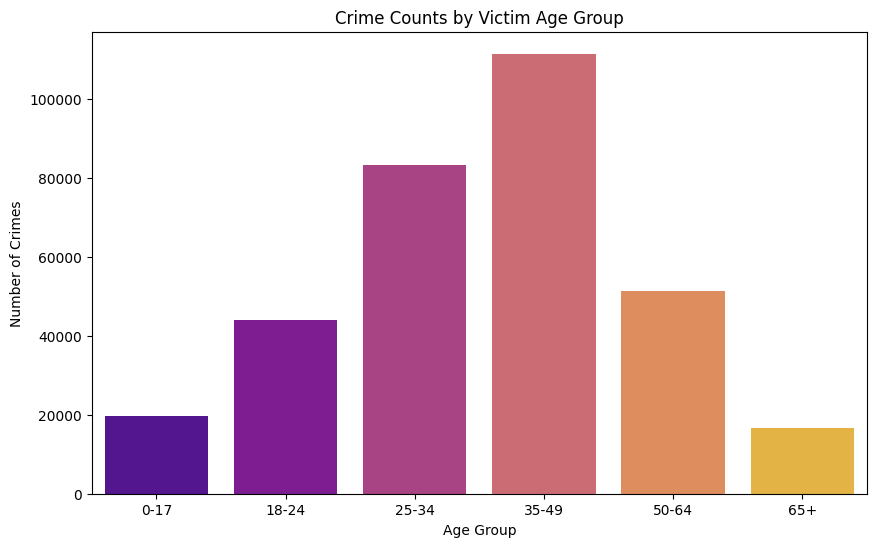


High-Risk Age Group: 35-49 (highest number of crimes)


In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(df['Vict Age'], bins=20, kde=True)
plt.title('Distribution of Victim Ages')
plt.xlabel('Victim Age')
plt.ylabel('Number of Crimes')
plt.show()

# To identify high-risk age groups, let's look at value counts for specific ranges
age_bins = [0, 18, 25, 35, 50, 65, 100]
age_labels = ['0-17', '18-24', '25-34', '35-49', '50-64', '65+']
df['Age Group'] = pd.cut(df['Vict Age'], bins=age_bins, labels=age_labels, right=False)
age_group_counts = df['Age Group'].value_counts().sort_index()

print("Crimes by Age Group:")
display(age_group_counts)

plt.figure(figsize=(10, 6))
sns.barplot(x=age_group_counts.index, y=age_group_counts.values, palette='plasma')
plt.title('Crime Counts by Victim Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Crimes')
plt.show()

# Identify the age group with the most crimes
high_risk_age_group = age_group_counts.idxmax()
print(f"\nHigh-Risk Age Group: {high_risk_age_group} (highest number of crimes)")

### 11. Gender Distribution

Victim Gender Distribution:


,proportion
Vict Sex,
M,48.416466
F,45.674124
X,5.901136
H,0.008274


/tmp/ipykernel_3204/445398040.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_distribution.index, y=gender_distribution.values, palette='coolwarm')


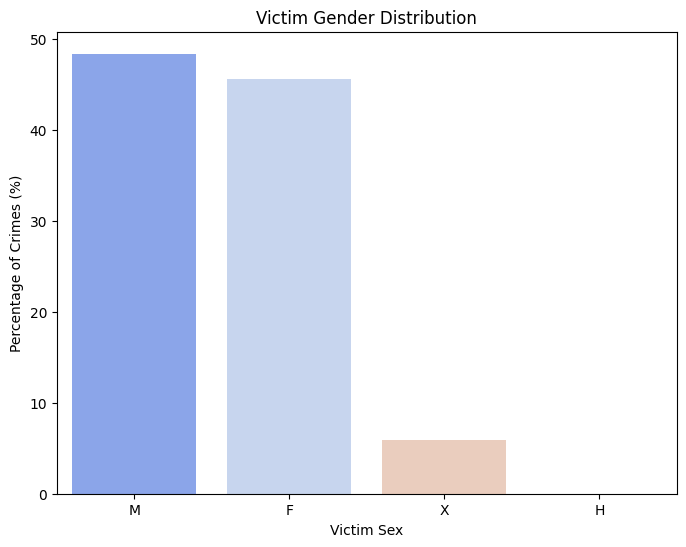

In [ ]:
gender_distribution = df['Vict Sex'].value_counts(normalize=True) * 100

print("Victim Gender Distribution:")
display(gender_distribution)

plt.figure(figsize=(8, 6))
sns.barplot(x=gender_distribution.index, y=gender_distribution.values, palette='coolwarm')
plt.title('Victim Gender Distribution')
plt.xlabel('Victim Sex')
plt.ylabel('Percentage of Crimes (%)')
plt.show()